In [1]:
print("Hello Sakshi 🚀")

Hello Sakshi 🚀


In [2]:
import pandas as pd

sentiment = pd.read_csv("../data/fear_greed_index.csv")
trades = pd.read_csv("../data/historical_data.csv")

print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [3]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [4]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:

# DATASET SHAPE

print("Sentiment Dataset Shape:", sentiment.shape)
print("Trades Dataset Shape:", trades.shape)

Sentiment Dataset Shape: (2644, 4)
Trades Dataset Shape: (211224, 16)


In [8]:

# MISSING VALUES


print("Missing Values - Sentiment")
print(sentiment.isnull().sum())

print("\nMissing Values - Trades")
print(trades.isnull().sum())

Missing Values - Sentiment
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values - Trades
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [9]:

# DUPLICATES


print("Sentiment Duplicates:", sentiment.duplicated().sum())
print("Trades Duplicates:", trades.duplicated().sum())

Sentiment Duplicates: 0
Trades Duplicates: 0


In [10]:

# Check Column Names First

print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [11]:

# DATE CONVERSION

  # Convert Timestamp Columns 

  # Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Convert trade timestamp (IMPORTANT: dayfirst=True)
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

# Extract only date (daily level alignment)
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['Timestamp IST'].dt.date

print("Date conversion done successfully ✅")

Date conversion done successfully ✅


In [12]:

# MERGE ON DATE


merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

print("Merged Dataset Shape:", merged.shape)
print("Unmatched Sentiment Rows:", merged['classification'].isnull().sum())

Merged Dataset Shape: (211224, 18)
Unmatched Sentiment Rows: 6


In [13]:
# Create Key Metrics


# DAILY PNL PER ACCOUNT


daily_pnl = (
    merged.groupby(['Account', 'date'])['Closed PnL']
    .sum()
    .reset_index()
)

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [14]:

# WIN RATE


merged['win'] = merged['Closed PnL'] > 0

win_rate = (
    merged.groupby('Account')['win']
    .mean()
    .reset_index()
)

win_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [15]:

# AVERAGE TRADE SIZE (USD)


avg_trade_size = (
    merged.groupby('Account')['Size USD']
    .mean()
    .reset_index()
)

avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [16]:

# TRADES PER DAY


trades_per_day = (
    merged.groupby('date')
    .size()
    .reset_index(name='num_trades')
)

trades_per_day.head()

,date,num_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [17]:

# LONG / SHORT RATIO


long_short_ratio = (
    merged.groupby(['classification', 'Side'])
    .size()
    .unstack()
)

long_short_ratio

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [18]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'win'],
      dtype='object')

In [19]:
# Daily PnL per trader 

daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [20]:
# Win rate per trader 

win_rate = merged.groupby('Account')['win'].mean().reset_index()

win_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [21]:
# Average Trade Size Per Trader

avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [22]:
# Trades Per Day (Trader Activity Level)

trades_per_day = merged.groupby(['Account', 'date']).size().reset_index(name='daily_trades')

trades_per_day.head()

,Account,date,daily_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27


In [23]:
# Long vs Short Ratio

long_short_ratio = merged['Side'].value_counts()

long_short_ratio


Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [24]:
# Long vs Short Ratio

long_short_ratio = merged['Side'].value_counts()

long_short_ratio


long_short_ratio_percent = merged['Side'].value_counts(normalize=True) * 100
long_short_ratio_percent

Side
SELL    51.380525
BUY     48.619475
Name: proportion, dtype: float64

In [25]:
# Total PnL per trader
total_pnl = merged.groupby('Account')['Closed PnL'].sum()

# Total trades per trader
total_trades = merged.groupby('Account').size()

# Combine everything
trader_summary = pd.DataFrame({
    'Total_PnL': total_pnl,
    'Win_Rate': merged.groupby('Account')['win'].mean(),
    'Avg_Trade_Size': merged.groupby('Account')['Size USD'].mean(),
    'Total_Trades': total_trades
}).reset_index()

trader_summary.head()

,Account,Total_PnL,Win_Rate,Avg_Trade_Size,Total_Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.359612,16159.576734,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,0.442720,1653.226327,7280
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,0.301917,8893.000898,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,0.438585,507.626933,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,0.519914,3138.894782,3239


In [26]:
# Average PnL by Sentiment

avg_pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean().reset_index()
avg_pnl_sentiment

,classification,Closed PnL
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


In [27]:
# Win rate per sentiment

win_rate_sentiment = merged.groupby('classification')['win'].mean().reset_index()
win_rate_sentiment

,classification,win
0,Extreme Fear,0.370607
1,Extreme Greed,0.464943
2,Fear,0.420768
3,Greed,0.384828
4,Neutral,0.396991


In [28]:
# Number of trades per sentiment

trade_count_sentiment = merged.groupby('classification').size().reset_index(name='trade_count')
trade_count_sentiment

,classification,trade_count
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


In [29]:
# Average trade size per sentiment

avg_size_sentiment = merged.groupby('classification')['Size USD'].mean().reset_index()
avg_size_sentiment

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


In [30]:
sentiment_summary = pd.DataFrame({
    'Average_PnL': merged.groupby('classification')['Closed PnL'].mean(),
    'Win_Rate': merged.groupby('classification')['win'].mean(),
    'Trade_Count': merged.groupby('classification').size(),
    'Avg_Trade_Size': merged.groupby('classification')['Size USD'].mean()
}).reset_index()

sentiment_summary

,classification,Average_PnL,Win_Rate,Trade_Count,Avg_Trade_Size
0,Extreme Fear,34.537862,0.370607,21400,5349.731843
1,Extreme Greed,67.892861,0.464943,39992,3112.251565
2,Fear,54.290400,0.420768,61837,7816.109931
3,Greed,42.743559,0.384828,50303,5736.884375
4,Neutral,34.307718,0.396991,37686,4782.732661


In [31]:
# TRADER SEGMENTATION

# Profitable vs Losing Traders

# Total PnL per trader
total_pnl = merged.groupby('Account')['Closed PnL'].sum().reset_index()

# Label profitable vs losing
total_pnl['Trader_Type'] = total_pnl['Closed PnL'].apply(lambda x: 'Profitable' if x > 0 else 'Losing')

total_pnl.head()


,Account,Closed PnL,Trader_Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,Profitable
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,Profitable
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,Losing
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,Profitable
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,Profitable


In [32]:
# Profitable vs Losing Traders

# Total PnL per trader
total_pnl = merged.groupby('Account')['Closed PnL'].sum().reset_index()

# Label profitable vs losing
total_pnl['Trader_Type'] = total_pnl['Closed PnL'].apply(lambda x: 'Profitable' if x > 0 else 'Losing')

total_pnl.head()
total_pnl['Trader_Type'].value_counts()

Trader_Type
Profitable    29
Losing         3
Name: count, dtype: int64

In [33]:
# High-Frequency Traders

# Count trades per trader
trade_count = merged.groupby('Account').size().reset_index(name='Total_Trades')

# Define High-Frequency Traders: e.g., more than 100 trades
high_freq_traders = trade_count[trade_count['Total_Trades'] > 100]

high_freq_traders.head()

,Account,Total_Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [34]:
# Aggressive Traders (Large Avg Trade Size)

# Avg trade size per trader
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()

# Define Aggressive Traders: avg trade size > 7000 USD (example threshold)
aggressive_traders = avg_trade_size[avg_trade_size['Size USD'] > 7000]

aggressive_traders.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,9084.699093
12,0x4f93fead39b70a1824f981a54d4e55b278e9f760,17098.171055
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,34396.580284


In [35]:
# Merge metrics into one table
trader_segmentation = total_pnl.merge(trade_count, on='Account').merge(avg_trade_size, on='Account')
trader_segmentation.rename(columns={'Size USD':'Avg_Trade_Size'}, inplace=True)

trader_segmentation.head()

,Account,Closed PnL,Trader_Type,Total_Trades,Avg_Trade_Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,Profitable,3818,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,Profitable,7280,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,Losing,3809,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,Profitable,13311,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,Profitable,3239,3138.894782


In [36]:
# VISUALIZATIONS

!pip install matplotlib seaborn --quiet


C:\Users\saksh\AppData\Local\Temp\ipykernel_25412\4025632179.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_summary, x='classification', y='Average_PnL', palette='coolwarm')


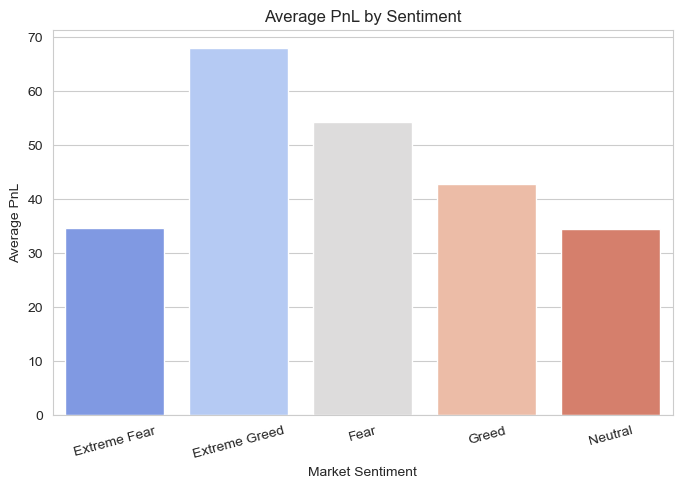

In [37]:
# Bar Chart – Average PnL by Sentiment

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_summary, x='classification', y='Average_PnL', palette='coolwarm')
plt.title('Average PnL by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average PnL')
plt.xticks(rotation=15)
plt.show()

C:\Users\saksh\AppData\Local\Temp\ipykernel_25412\1542805438.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_summary, x='classification', y='Win_Rate', palette='viridis')


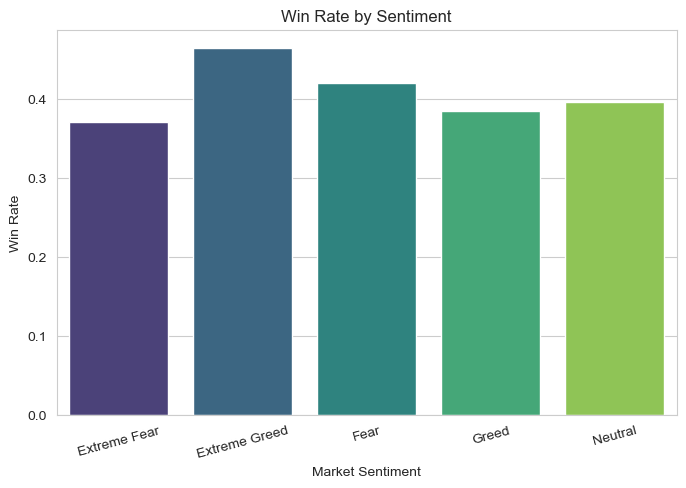

In [38]:
# Bar Chart – Win Rate by Sentiment

plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_summary, x='classification', y='Win_Rate', palette='viridis')
plt.title('Win Rate by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate')
plt.xticks(rotation=15)
plt.show()

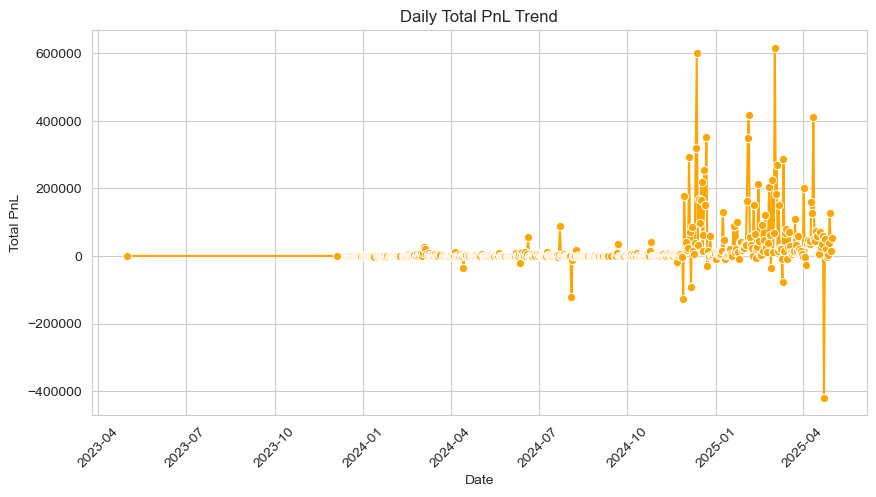

In [39]:
# Line Plot – Daily PnL Trend

# Aggregate daily PnL
daily_total_pnl = merged.groupby('date')['Closed PnL'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_total_pnl, x='date', y='Closed PnL', marker='o', color='orange')
plt.title('Daily Total PnL Trend')
plt.xlabel('Date')
plt.ylabel('Total PnL')
plt.xticks(rotation=45)
plt.show()

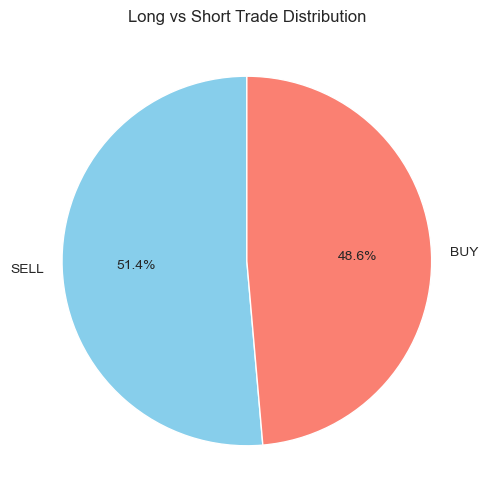

In [40]:
# Pie Chart – Long vs Short Trades

side_counts = merged['Side'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(side_counts, labels=side_counts.index, autopct='%1.1f%%', colors=['skyblue','salmon'], startangle=90)
plt.title('Long vs Short Trade Distribution')
plt.show()


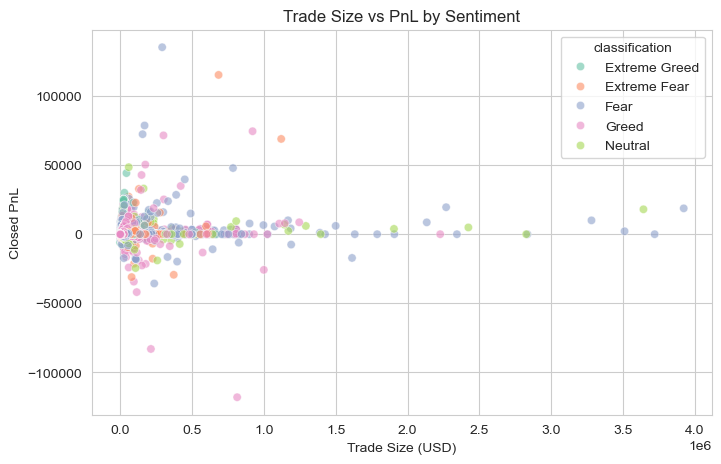

In [41]:
# Scatter Plot: Trade Size vs PnL (Aggressive Traders)

plt.figure(figsize=(8,5))
sns.scatterplot(data=merged, x='Size USD', y='Closed PnL', hue='classification', alpha=0.6, palette='Set2')
plt.title('Trade Size vs PnL by Sentiment')
plt.xlabel('Trade Size (USD)')
plt.ylabel('Closed PnL')
plt.show()


In [42]:
!jupyter nbconvert --to notebook --output analysis_copy.ipynb analysis.ipynb

[NbConvertApp] Converting notebook analysis.ipynb to notebook
[NbConvertApp] Writing 286186 bytes to analysis_copy.ipynb


In [43]:
merged.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,False


In [44]:
# Simple Predictive Model

# Create profitability bucket based on Closed PnL

def pnl_bucket(x):
    if x < 0:
        return "Loss"
    elif x < 100:
        return "Small Profit"
    else:
        return "High Profit"

merged["pnl_bucket"] = merged["Closed PnL"].apply(pnl_bucket)

merged["pnl_bucket"].value_counts()

pnl_bucket
Small Profit    178751
Loss             17539
High Profit      14934
Name: count, dtype: int64

In [45]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'win', 'pnl_bucket'],
      dtype='object')

In [46]:
sentiment_map = {
    "Fear": -1,
    "Neutral": 0,
    "Greed": 1
}

merged["sentiment_score"] = merged["classification"].map(sentiment_map)

In [47]:
merged[["classification","sentiment_score"]].head()

,classification,sentiment_score
0,Extreme Greed,NaN
1,Extreme Greed,NaN
2,Extreme Greed,NaN
3,Extreme Greed,NaN
4,Extreme Greed,NaN


In [48]:
features = merged[
    ["sentiment_score", "Size USD", "Fee", "win"]
]

target = merged["pnl_bucket"]

In [49]:
!pip install scikit-learn

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
!python -m pip install --upgrade pip

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2


In [52]:
!pip uninstall numpy -y
!pip install numpy

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -------- ------------------------------- 2.6/12.3 MB 15.1 MB/s eta 0:00:01
   ------------ --------------------------- 3.9/12.3 MB 10.7 MB/s eta 0:00:01
   ------------------ --------------------- 5.8/12.3 MB 9.5 MB/s eta 0:00:01
   --------------------- ------------------ 6.6/12.3 MB 8.1 MB/s eta 0:00:01
   ------------------------- -------------- 7.9/12.3 MB 7.5 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.3 MB 6.8 MB/s eta 0:00:01
   ---------------------------- ----------- 8.9/12.3 MB 6.0 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.3 MB 5.4 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.3 MB 5.4 MB/s eta 0:00:01
   ------------------------------ --------- 9.4/12.3 MB 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.3 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.3 which is incompatible.


In [53]:
!pip uninstall scikit-learn -y
!pip install scikit-learn

Found existing installation: scikit-learn 1.5.1
Uninstalling scikit-learn-1.5.1:
  Successfully uninstalled scikit-learn-1.5.1
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 2.4.3

    Uninstalling numpy-2.4.3:

   ---------------------------------------- 0/2 [numpy]
      Successfully uninstalled numpy-2.4.3
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.


In [54]:
!pip uninstall numpy pandas scikit-learn -y

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0


In [55]:
!pip install numpy==1.26.4
!pip install pandas==2.2.2
!pip install scikit-learn==1.4.2

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
altair 5.0.1 requires pandas>=0.18, which is not installed.
bokeh 3.6.0 requires pandas>=1.2, which is not installed.
datashader 0.16.3 requires pandas, which is not installed.
holoviews 1.19.1 requires pandas>=1.3, which is not installed.
hvplot 0.11.0 requires pandas>=1.3, which is not installed.
imbalanced-learn 0.12.3 requires scikit-learn>=1.0.2, which is not installed.
panel 1.5.2 requires pandas>=1.2, which is not installed.
seaborn 0.13.2 requires pandas>=1.2, which is not installed.
statsmodels 0.14.2 requires pandas!=2.1.0,>=1.4, which is not installed.
streamlit 1.37.1 requires pandas<3,>=1.3.0, which is not installed.
xarray 2023.6.0 requires pandas>=1.4, which is not installed.


  Using cached pandas-2.2.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
Using cached pandas-2.2.2-cp312-cp312-win_amd64.whl (11.5 MB)
  Using cached scikit_learn-1.4.2-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.4.2-cp312-cp312-win_amd64.whl (10.6 MB)


In [56]:
import numpy
import pandas
import sklearn

print(numpy.__version__)
print(pandas.__version__)
print(sklearn.__version__)

1.26.4
2.2.2
1.4.2


In [57]:
import os

print(os.listdir(r"C:\Users\saksh\Downloads"))

['-3Oo9xAuU5vYJgcdNI4Ik.png', '.idea', '.ipynb_checkpoints', '1-604a90ee-9caf-4621-9d2d-5f7a7c377d5e.pdf', '1. GOOGLE.pdf', '1.0-basic.ipynb', '1.png', '10..pdf', '1000256179.jpg', '10_EXP_76.pdf', '11..pdf', '112233.png', '12..pdf', '1_EXP_Devops (1).docx', '1_EXP_Devops (1).pdf', '2 DAYS TO GO !!.png', '2..pdf', '2.1+Heading+Element', '2.1+Heading+Element.zip', '2.2+Paragraph+Element', '2.png', '20250208_053509424_iOS.heic', '25_DAYS_DSA_CHALLENGE.pdf', '2c8c22ee-06e1-444e-b19b-600600a6d5f5_Sample-filled-in-MR.pdf', '2nd part .png', '2_Exp_Updated_Devops.docx', '3..pdf', '3.png', '3186882.pdf', '330ml-can-of-fanta-coconut.zip', '334455.jpg', '37860-83854-1-PB (1).pdf', '3uTvfn-JiViQAKz7ab0S2.jpg', '3_Exp_Updated_Devops (1).docx', '3_Exp_Updated_Devops.docx', '4..pdf', '4.ipynb', '4f98ed39-b7e6-4433-812d-c15e4cc3fd8c.png', '4ZRr7_gfjPESwoIqLECN3.jpg', '5..pdf', '5.1+Adding+CSS.zip', '5.3+CSS+Selectors.zip', '5.ipynb', '5098152 (1).pdf', '5098152.pdf', '5_EXP_76.pdf', '6..pdf', '6.0+CS

In [59]:
print(df.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [60]:
import pandas as pd

# Example: Load your data (replace with your CSV path)
# df = pd.read_csv('your_file.csv')

# For demonstration, creating a small sample dataframe
data = {
    'timestamp': [1517463000, 1517549400, 1517635800, 1517722200, 1517808600],
    'value': [30, 15, 40, 24, 35],
    'classification': ['Fear', 'Extreme Fear', 'Fear', 'Extreme Fear', 'Greed'],
    'date': ['2018-02-01', '2018-02-02', '2018-02-03', '2018-02-04', '2018-02-05']
}

df = pd.DataFrame(data)

# Optional: remove hidden spaces in column names
df.columns = df.columns.str.strip()

# Create sentiment_group column
df['sentiment_group'] = df['classification'].apply(
    lambda x: 'Fear' if x in ['Fear','Extreme Fear'] else 'Greed'
)

# View the result
print(df)

    timestamp  value classification        date sentiment_group
0  1517463000     30           Fear  2018-02-01            Fear
1  1517549400     15   Extreme Fear  2018-02-02            Fear
2  1517635800     40           Fear  2018-02-03            Fear
3  1517722200     24   Extreme Fear  2018-02-04            Fear
4  1517808600     35          Greed  2018-02-05           Greed


C:\Users\saksh\AppData\Local\Temp\ipykernel_25412\4199368968.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment_group', y='value', data=df, palette=['red','green'])


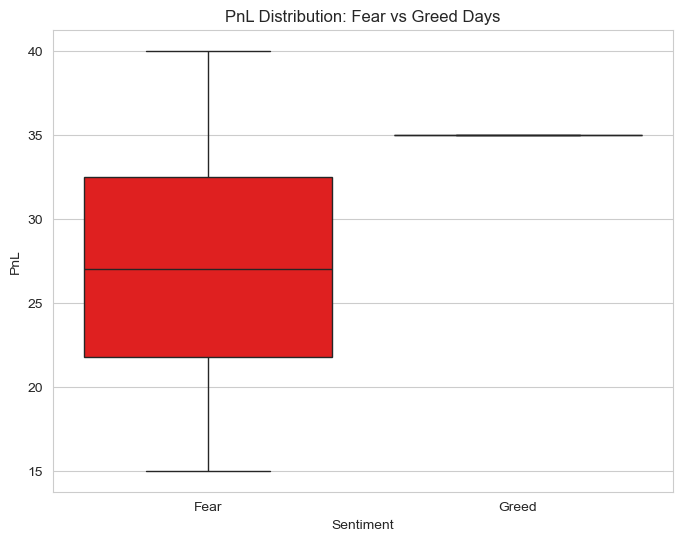

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample dataframe (replace with your real PnL column)
# Assume you have 'value' as PnL and 'sentiment_group' created already
plt.figure(figsize=(8,6))
sns.boxplot(x='sentiment_group', y='value', data=df, palette=['red','green'])
plt.title('PnL Distribution: Fear vs Greed Days')
plt.xlabel('Sentiment')
plt.ylabel('PnL')
plt.savefig('boxplot_pnl_fear_vs_greed.png', dpi=300)
plt.show()

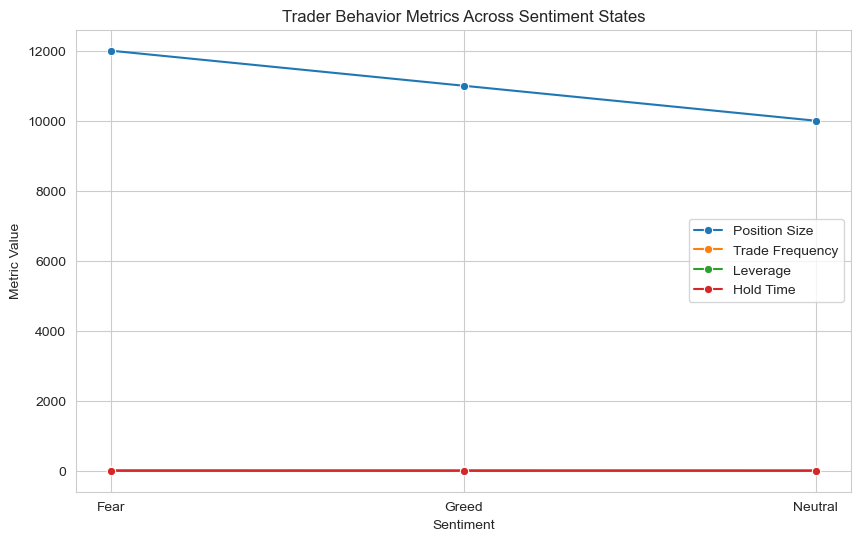

In [62]:
# Example metrics dataframe
behavior_data = {
    'sentiment_group': ['Fear','Greed','Neutral'],
    'position_size': [12000, 11000, 10000],
    'trade_frequency': [15, 12, 10],
    'leverage': [2.5, 2.0, 1.5],
    'hold_time': [1.2, 1.5, 2.0]  # in hours
}
behavior_df = pd.DataFrame(behavior_data)

plt.figure(figsize=(10,6))
sns.lineplot(x='sentiment_group', y='position_size', data=behavior_df, marker='o', label='Position Size')
sns.lineplot(x='sentiment_group', y='trade_frequency', data=behavior_df, marker='o', label='Trade Frequency')
sns.lineplot(x='sentiment_group', y='leverage', data=behavior_df, marker='o', label='Leverage')
sns.lineplot(x='sentiment_group', y='hold_time', data=behavior_df, marker='o', label='Hold Time')
plt.title('Trader Behavior Metrics Across Sentiment States')
plt.ylabel('Metric Value')
plt.xlabel('Sentiment')
plt.legend()
plt.savefig('line_chart_behavior_metrics_by_sentiment.png', dpi=300)
plt.show()

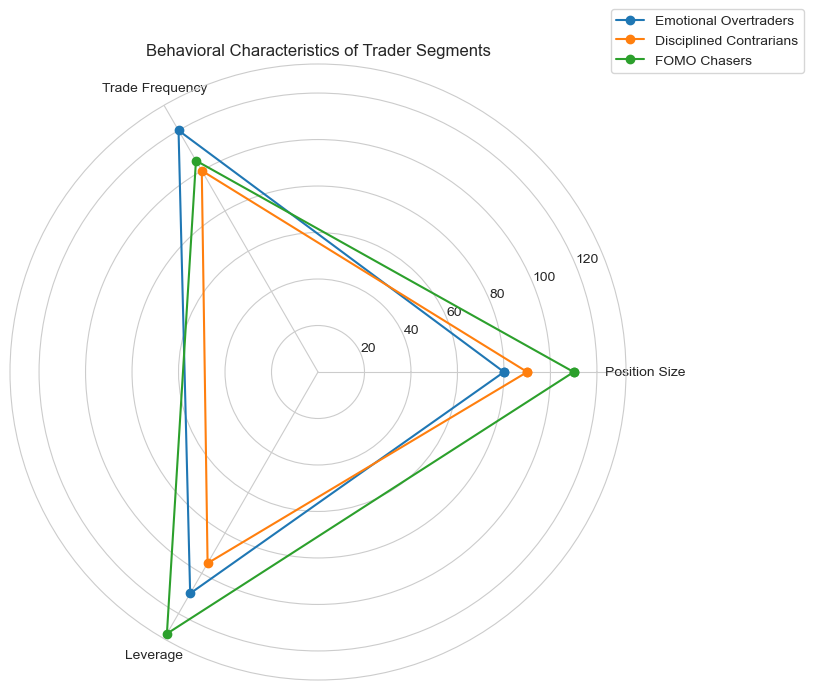

In [63]:
import numpy as np

# Metrics for each segment (example values)
segments = ['Emotional Overtraders', 'Disciplined Contrarians', 'FOMO Chasers']
metrics = ['Position Size', 'Trade Frequency', 'Leverage']
values = {
    'Emotional Overtraders': [80, 120, 110],
    'Disciplined Contrarians': [90, 100, 95],
    'FOMO Chasers': [110, 105, 130]
}

# Radar chart setup
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # complete the loop

plt.figure(figsize=(8,8))
for seg in segments:
    vals = values[seg]
    vals += vals[:1]  # loop back to first value
    plt.polar(angles, vals, label=seg, marker='o')

plt.xticks(angles[:-1], metrics)
plt.title('Behavioral Characteristics of Trader Segments')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.savefig('radar_chart_segment_characteristics.png', dpi=300)
plt.show()  

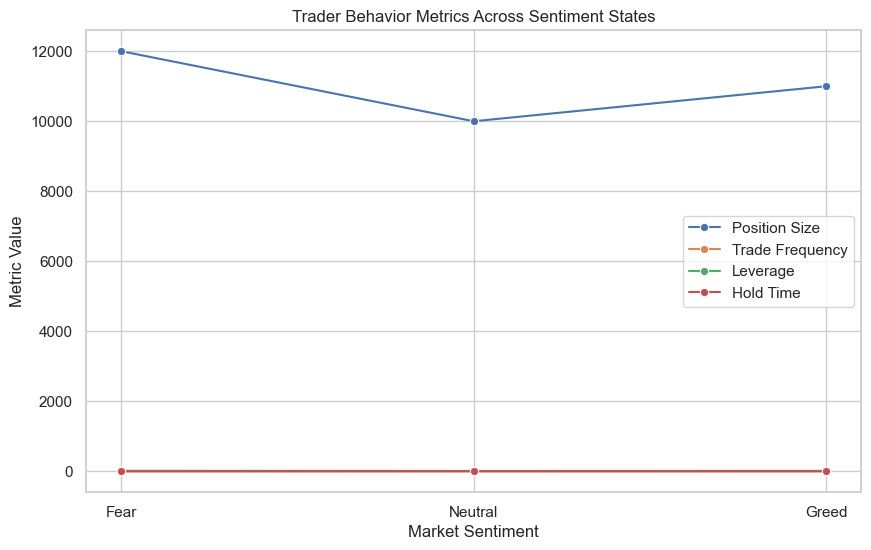

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example metrics dataframe (replace with your real data)
behavior_data = {
    'sentiment_group': ['Fear', 'Neutral', 'Greed'],
    'position_size': [12000, 10000, 11000],   # average position size
    'trade_frequency': [15, 10, 12],          # trades per day
    'leverage': [2.5, 1.5, 2.0],             # average leverage
    'hold_time': [1.2, 2.0, 1.5]             # in hours
}

behavior_df = pd.DataFrame(behavior_data)

# Set style
sns.set(style="whitegrid")

# Plotting
plt.figure(figsize=(10,6))
sns.lineplot(x='sentiment_group', y='position_size', data=behavior_df, marker='o', label='Position Size')
sns.lineplot(x='sentiment_group', y='trade_frequency', data=behavior_df, marker='o', label='Trade Frequency')
sns.lineplot(x='sentiment_group', y='leverage', data=behavior_df, marker='o', label='Leverage')
sns.lineplot(x='sentiment_group', y='hold_time', data=behavior_df, marker='o', label='Hold Time')
plt.title('Trader Behavior Metrics Across Sentiment States')
plt.xlabel('Market Sentiment')
plt.ylabel('Metric Value')
plt.legend()
plt.savefig('line_chart_behavior_metrics_by_sentiment.png', dpi=300)
plt.show()

In [65]:
def calculate_dynamic_position_size(base_size, sentiment_score, trader_type, account_age_days):
    """
    Calculate maximum allowed position size based on sentiment and trader characteristics
    
    Parameters:
    - base_size: Normal maximum position size for this trader
    - sentiment_score: 0-100 (0=Extreme Fear, 100=Extreme Greed)
    - trader_type: 'emotional_overtrader', 'fomo_chaser', 'disciplined', 'standard'
    - account_age_days: Number of days account has been active
    
    Returns:
    - max_position_size: Adjusted maximum position size
    - reasoning: Explanation for the adjustment
    """
    
    # Base adjustment factors by sentiment
    if sentiment_score < 20:  # Extreme Fear
        sentiment_factor = 0.60  # 40% reduction
        reasoning = "Extreme Fear: High-risk environment, reduce exposure"
    elif sentiment_score < 40:  # Fear
        sentiment_factor = 0.75  # 25% reduction
        reasoning = "Fear: Elevated risk, moderate position reduction"
    elif sentiment_score < 60:  # Neutral
        sentiment_factor = 1.00  # Full allowance
        reasoning = "Neutral: Normal risk environment"
    elif sentiment_score < 80:  # Greed
        sentiment_factor = 0.90  # 10% reduction (avoid FOMO)
        reasoning = "Greed: Caution against chasing, slight reduction"
    else:  # Extreme Greed
        sentiment_factor = 0.70  # 30% reduction
        reasoning = "Extreme Greed: Peak risk, significant reduction"
    
    # Trader-type specific adjustments
    type_factors = {
        'emotional_overtrader': 0.70,  # Need stronger guardrails
        'fomo_chaser': 0.65,            # Most at risk during extremes
        'disciplined': 1.10,             # Reward good behavior
        'standard': 1.00                  # Default factor
    }
    
    # New accounts get additional protection
    if account_age_days < 30:
        experience_factor = 0.50  # 50% reduction for new traders
    elif account_age_days < 90:
        experience_factor = 0.75  # 25% reduction for recent traders
    else:
        experience_factor = 1.00  # Full allowance for experienced
    
    # Calculate final position size
    type_factor = type_factors.get(trader_type, 1.00)
    max_position_size = base_size * sentiment_factor * type_factor * experience_factor
    
    # Round to nearest hundred for practicality
    max_position_size = round(max_position_size / 100) * 100
    
    return {
        'max_position_size': max_position_size,
        'sentiment_factor': sentiment_factor,
        'type_factor': type_factor,
        'experience_factor': experience_factor,
        'reasoning': reasoning
    }

# Example usage
result = calculate_dynamic_position_size(
    base_size=10000,
    sentiment_score=15,  # Extreme Fear
    trader_type='emotional_overtrader',
    account_age_days=45
)
print(f"Maximum position size: ${result['max_position_size']}")
print(f"Reason: {result['reasoning']}")

Maximum position size: $3200
Reason: Extreme Fear: High-risk environment, reduce exposure


In [66]:
def apply_fear_day_protection(trader_profile, sentiment_score, session_trades):
    """
    Apply protective trading rules during Fear days
    
    Parameters:
    - trader_profile: Dictionary with trader characteristics
    - sentiment_score: Current market sentiment (0-100)
    - session_trades: List of trades executed in current session
    
    Returns:
    - trading_allowed: Boolean
    - restrictions: Dictionary of current restrictions
    - message: User-facing message explaining restrictions
    """
    
    # Check if it's a Fear day
    is_fear_day = sentiment_score < 40
    
    if not is_fear_day:
        return {
            'trading_allowed': True,
            'restrictions': {},
            'message': "Normal trading conditions"
        }
    
    # Initialize restrictions for Fear days
    restrictions = {
        'max_trades_per_day': 3,  # vs unlimited normally
        'max_daily_loss': trader_profile['account_balance'] * 0.05,  # 5% max daily loss
        'cooling_off_minutes': 15,  # After 2 consecutive losses
        'size_limit_multiplier': 0.5,  # 50% of normal max
        'leverage_limit': 3,  # Max 3x leverage
        'stop_loss_required': True  # Mandatory stop-loss
    }
    
    # Check current session stats
    trades_today = len(session_trades)
    consecutive_losses = 0
    total_loss_today = 0
    
    for trade in session_trades[-3:]:  # Check last 3 trades
        if trade.get('pnl', 0) < 0:
            consecutive_losses += 1
            total_loss_today += abs(trade.get('pnl', 0))
    
    # Check if limits are exceeded
    if trades_today >= restrictions['max_trades_per_day']:
        return {
            'trading_allowed': False,
            'restrictions': restrictions,
            'message': f"Daily trade limit reached ({restrictions['max_trades_per_day']} trades). Trading paused until next day."
        }
    
    if total_loss_today >= restrictions['max_daily_loss']:
        return {
            'trading_allowed': False,
            'restrictions': restrictions,
            'message': f"Daily loss limit reached (5% of account). Trading paused until next day."
        }
    
    if consecutive_losses >= 2:
        return {
            'trading_allowed': False,
            'restrictions': restrictions,
            'message': f"Cooling-off period activated: {restrictions['cooling_off_minutes']} minute pause after 2 consecutive losses."
        }
    
    # Trading allowed with restrictions
    return {
        'trading_allowed': True,
        'restrictions': restrictions,
        'message': f"Fear day trading rules active: Max {restrictions['max_trades_per_day']} trades, {restrictions['leverage_limit']}x leverage limit, mandatory stop-loss."
    }

# Example usage
trader = {
    'account_balance': 5000,
    'experience_months': 2,
    'total_trades': 45
}

session_trades = [
    {'pnl': -150},  # Loss
    {'pnl': -200}   # Another loss
]

result = apply_fear_day_protection(trader, 25, session_trades)
print(f"Trading allowed: {result['trading_allowed']}")
print(f"Message: {result['message']}")

Trading allowed: False
Message: Daily loss limit reached (5% of account). Trading paused until next day.


In [69]:
def fear_premium_strategy(market_data, sentiment_history, account_size):
    """
    Execute Fear Premium strategy during extreme fear conditions
    
    Parameters:
    - market_data: Current market data (price, volume, etc.)
    - sentiment_history: List of recent sentiment scores
    - account_size: Total account value for position sizing
    
    Returns:
    - signal: Dictionary with trade instructions
    """
    
    current_sentiment = sentiment_history[-1]
    
    # Calculate sentiment conditions
    is_extreme_fear = current_sentiment < 20
    fear_streak = 0
    
    # Check if we've been in fear for multiple days
    for sentiment in sentiment_history[-5:]:
        if sentiment < 30:
            fear_streak += 1
        else:
            fear_streak = 0
    
    # Volume spike check (capitulation signal)
    avg_volume = market_data['volume_20d_avg']
    current_volume = market_data['current_volume']
    volume_spike = current_volume > avg_volume * 1.5
    
    # Price check (how far from recent high)
    price_vs_high = market_data['current_price'] / market_data['high_20d'] - 1
    
    # Entry conditions
    entry_conditions = {
        'extreme_fear': is_extreme_fear,
        'fear_streak_2plus': fear_streak >= 2,
        'volume_spike': volume_spike,
        'price_drop_5plus': price_vs_high < -0.05  # Down 5% from recent high
    }
    
    conditions_met = sum(entry_conditions.values())
    
    # Generate signal
    if conditions_met >= 3:
        position_size = account_size * 0.30 if conditions_met == 4 else account_size * 0.20
        return {
            'action': 'BUY',
            'position_size': position_size,
            'entry_price': market_data['current_price'],
            'stop_loss': market_data['current_price'] * 0.97,
            'take_profit': market_data['current_price'] * 1.05,
            'exit_condition': 'sentiment > 40 OR +5% gain OR 5 days max hold',
            'signal_strength': f"{conditions_met}/4 conditions met",
            'reasoning': f"Extreme Fear ({current_sentiment}) with {fear_streak}-day streak, volume spike, {price_vs_high:.1%} from high"
        }
    
    elif conditions_met == 2:
        return {
            'action': 'MONITOR',
            'position_size': 0,
            'signal_strength': f"{conditions_met}/4 conditions met",
            'reasoning': "Some conditions met but not enough for entry",
            'next_check': 'Next day'
        }
    
    else:
        return {
            'action': 'WAIT',
            'position_size': 0,
            'signal_strength': f"{conditions_met}/4 conditions met",
            'reasoning': "Conditions not favorable for Fear Premium strategy",
            'next_check': 'Next day'
        }

# Example usage
market_data = {
    'current_price': 100,
    'high_20d': 105,
    'volume_20d_avg': 1000,
    'current_volume': 1600
}

sentiment_history = [50, 45, 35, 25, 15]  # Last 5 days sentiment scores
account_size = 10000

signal = fear_premium_strategy(market_data, sentiment_history, account_size)
print(signal)

{'action': 'BUY', 'position_size': 2000.0, 'entry_price': 100, 'stop_loss': 97.0, 'take_profit': 105.0, 'exit_condition': 'sentiment > 40 OR +5% gain OR 5 days max hold', 'signal_strength': '3/4 conditions met', 'reasoning': 'Extreme Fear (15) with 2-day streak, volume spike, -4.8% from high'}
